# Monitor RL training — `08-monitor-rl-training`

Reads the TensorBoard event files written by `src.rl.train` into `runs/<EXPERIMENT>/`
and renders the learning, loss, and CRN-eval curves inline.  Equivalent to opening
TensorBoard locally (`uv run tensorboard --logdir runs/`) but works fully offline and
lets you slice the data programmatically.

**Experiment variable:** `EXPERIMENT` at the top of the next cell.  Change it to the
folder name of any other training run under `RUNS_ROOT` and re-run the notebook —
no other edits required.

**Generating the `rl_ppo` run:** run a quick smoke training first:
```bash
uv run python -m src.rl.train --total-env-steps 5000 --n-envs 2 --experiment-name rl_ppo --no-eval
```
A full training run (1 M steps, ~20 min on CPU) with eval enabled populates the
`eval/*` curves shown in section 4.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import os
from pathlib import Path

while not (Path.cwd() / 'pyproject.toml').exists():
    os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 4)

## 1. Pick an experiment

`RUNS_ROOT` mirrors `--tb-log-dir` / `--checkpoint-dir` (default `runs/`).
`EXPERIMENT` mirrors `--experiment-name` (default `rl_ppo`).
Edit this cell and re-run the notebook to switch to a different training run.

In [2]:
# ── Editable top-of-notebook variables ───────────────────────────────────────
RUNS_ROOT = Path('runs')
EXPERIMENT = 'rl_ppo'   # change to any folder under RUNS_ROOT
# ──────────────────────────────────────────────────────────────────────────────

EXP_DIR = RUNS_ROOT / EXPERIMENT
assert EXP_DIR.exists(), (
    f'Experiment dir not found: {EXP_DIR}. '
    f'Run `uv run python -m src.rl.train --experiment-name {EXPERIMENT} ...` first.'
)

print(f'Experiment directory: {EXP_DIR}')
print('Event files:')
for p in sorted(EXP_DIR.glob('events.out.tfevents.*')):
    size_kb = p.stat().st_size / 1024.0
    print(f'  {p.name}  ({size_kb:.1f} KB)')
print(f'\nAll runs available under {RUNS_ROOT}:')
for d in sorted(RUNS_ROOT.iterdir()):
    if d.is_dir():
        print(f'  {d.name}')

Experiment directory: runs/rl_ppo
Event files:
  events.out.tfevents.1780565020.device-102.home.74785.0  (8.7 KB)

All runs available under runs:
  example_chain_three_node
  example_two_factories_two_shops
  fashion_run
  rl_ppo
  smoke
  tuning


## 2. Load all scalar tags

`EventAccumulator` is the same reader TensorBoard uses internally.
`size_guidance={'scalars': 0}` disables downsampling so every recorded point
comes through regardless of run length.

In [3]:
ea = EventAccumulator(str(EXP_DIR), size_guidance={'scalars': 0})
ea.Reload()
tags = ea.Tags()['scalars']

def scalars_to_df(tag: str) -> pd.DataFrame:
    """Return a DataFrame with columns [step, value] for *tag*."""
    events = ea.Scalars(tag)
    return pd.DataFrame({'step': [e.step for e in events],
                         'value': [e.value for e in events]})

print(f'Scalar tags ({len(tags)} total):')
for t in sorted(tags):
    df = scalars_to_df(t)
    print(f'  {t:<40s}  {len(df):>5d} steps')

Scalar tags (9 total):
  charts/SPS                                   19 steps
  charts/learning_rate                         19 steps
  losses/approx_kl                             19 steps
  losses/clipfrac                              19 steps
  losses/entropy                               19 steps
  losses/policy_loss                           19 steps
  losses/value_loss                            19 steps
  train/episodic_length                        13 steps
  train/episodic_return                        13 steps


## 3. Learning curves

**`train/episodic_return`** — cumulative reward (cash delta) of each completed
episode sampled during training.  A rising trend indicates the policy is learning
to generate more profit.

**`charts/SPS`** — environment steps per second; a proxy for throughput.

**`charts/learning_rate`** — Adam learning rate, linearly annealed from `lr`
(default `3e-4`) down to 0 over the course of training, so this curve decays
steadily.

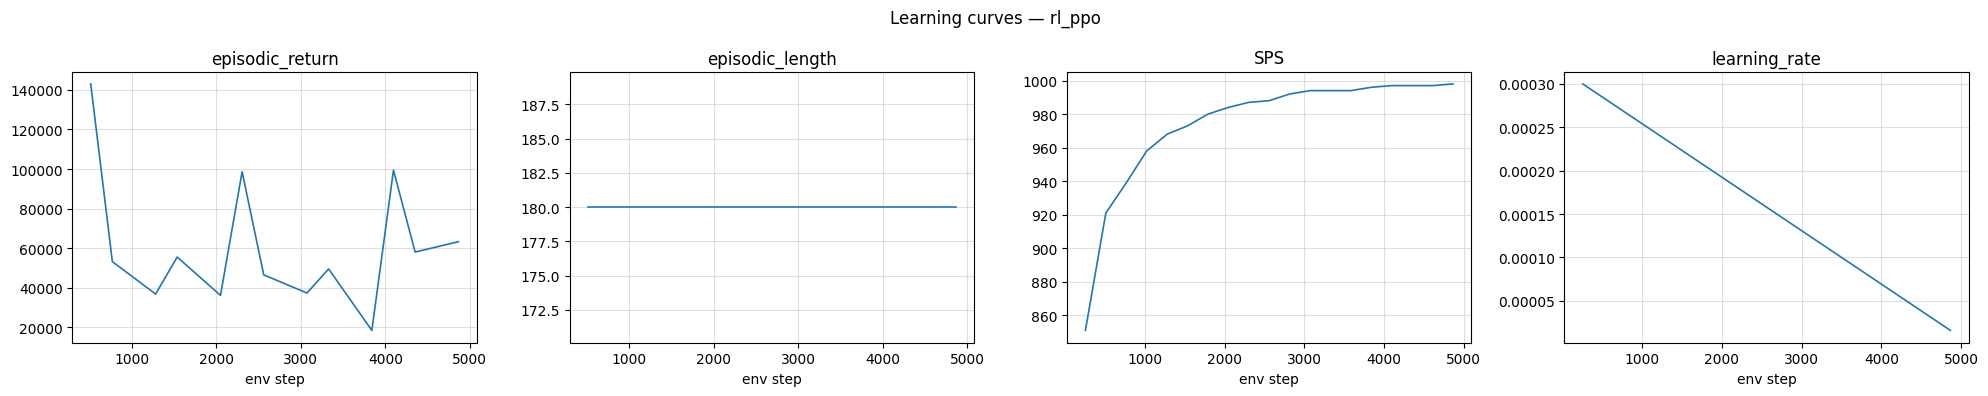

In [4]:
learning_tags = ['train/episodic_return', 'train/episodic_length',
                  'charts/SPS', 'charts/learning_rate']
available_learning = [t for t in learning_tags if t in tags]

if available_learning:
    n = len(available_learning)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, tag in zip(axes, available_learning):
        df = scalars_to_df(tag)
        ax.plot(df['step'], df['value'], linewidth=1.2)
        ax.set_title(tag.split('/')[-1])
        ax.set_xlabel('env step')
        ax.grid(True, alpha=0.4)
    fig.suptitle(f'Learning curves — {EXPERIMENT}', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print('No learning-curve tags found in this run.')

## 4. PPO loss panel

The five standard PPO diagnostics:

- **`losses/value_loss`** — critic MSE; should decrease as the value function improves.
- **`losses/policy_loss`** — clipped surrogate objective (negative = improving).
- **`losses/entropy`** — action-distribution entropy; higher = more exploration.
- **`losses/approx_kl`** — approximate KL between old and new policy; large spikes
  suggest the update is too aggressive (lower `lr` or enable `target_kl`).
- **`losses/clipfrac`** — fraction of minibatch steps that hit the PPO clip;
  consistently near 1.0 also suggests aggressive updates.

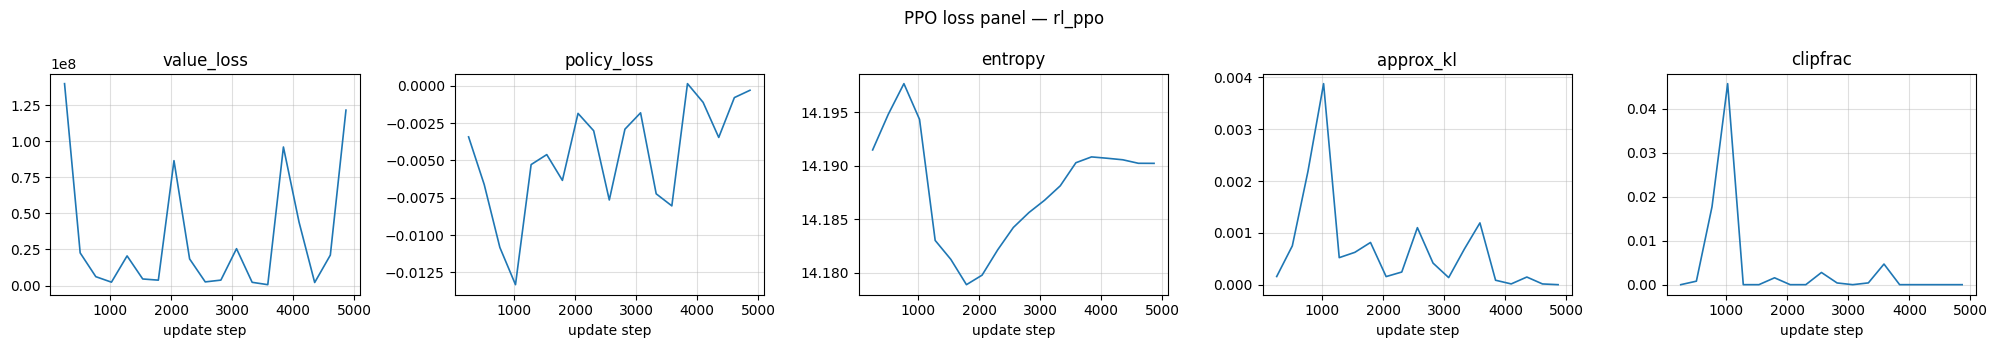

In [5]:
loss_tags = ['losses/value_loss', 'losses/policy_loss', 'losses/entropy',
             'losses/approx_kl', 'losses/clipfrac']
available_loss = [t for t in loss_tags if t in tags]

if available_loss:
    n = len(available_loss)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 3.5))
    if n == 1:
        axes = [axes]
    for ax, tag in zip(axes, available_loss):
        df = scalars_to_df(tag)
        ax.plot(df['step'], df['value'], linewidth=1.2)
        ax.set_title(tag.split('/')[-1])
        ax.set_xlabel('update step')
        ax.grid(True, alpha=0.4)
    fig.suptitle(f'PPO loss panel — {EXPERIMENT}', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print('No loss tags found in this run.')

## 5. CRN evaluation curves

These tags are written when `--eval` is enabled (default cadence: every 50k env
steps).  They are absent from short smoke runs.

- **`eval/paired_uplift`** — mean of `(RL return − baseline return)` across the
  32 held-out CRN seeds.  Positive and stable = the policy genuinely beats
  `OrderUpToPolicy` on bit-identical worlds.
- **`eval/win_rate`** — fraction of seeds where RL > baseline.
- **`eval/rl_return` vs `eval/baseline_return`** — raw return levels (not paired).

In [6]:
eval_tags = ['eval/paired_uplift', 'eval/win_rate',
             'eval/rl_return', 'eval/baseline_return']
available_eval = [t for t in eval_tags if t in tags]

if available_eval:
    n = len(available_eval)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, tag in zip(axes, available_eval):
        df = scalars_to_df(tag)
        ax.plot(df['step'], df['value'], marker='o', markersize=3, linewidth=1.2)
        ax.set_title(tag.split('/')[-1])
        ax.set_xlabel('env step')
        ax.grid(True, alpha=0.4)
    fig.suptitle(f'CRN eval curves — {EXPERIMENT}', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print(
        'No eval/* tags found.  Eval tags are written when training is run with '
        'the CRN eval callback enabled (omit --no-eval, or use a longer training run).'
    )

No eval/* tags found.  Eval tags are written when training is run with the CRN eval callback enabled (omit --no-eval, or use a longer training run).


## 6. Latest-value snapshot

A quick summary table of the most recent value for every scalar tag in the run.

In [7]:
rows = []
for tag in sorted(tags):
    df = scalars_to_df(tag)
    rows.append({'tag': tag, 'n_steps': len(df),
                 'last_step': int(df['step'].iloc[-1]),
                 'last_value': float(df['value'].iloc[-1])})
snapshot = pd.DataFrame(rows)
display(snapshot.style.format({'last_value': '{:.4f}'}))

,tag,n_steps,last_step,last_value
0,charts/SPS,19,4864,998.0000
1,charts/learning_rate,19,4864,0.0000
2,losses/approx_kl,19,4864,0.0000
3,losses/clipfrac,19,4864,0.0000
4,losses/entropy,19,4864,14.1902
5,losses/policy_loss,19,4864,-0.0003
6,losses/value_loss,19,4864,121564632.0000
7,train/episodic_length,13,4864,180.0000
8,train/episodic_return,13,4864,63218.5000


## 7. Checkpoint listing

The training driver saves one checkpoint per eval call (at `eval_cadence_env_steps`)
plus a final checkpoint at the end of the run.  Use the path from this listing
as `CHECKPOINT_PATH` in `09-rl-vs-baseline.ipynb`.

In [8]:
ckpt_dir = EXP_DIR / 'checkpoints'
if ckpt_dir.exists():
    ckpts = sorted(ckpt_dir.glob('actor_step*.pt'))
    if ckpts:
        print(f'Checkpoints under {ckpt_dir}:')
        for p in ckpts:
            size_kb = p.stat().st_size / 1024.0
            print(f'  {p.name}  ({size_kb:.1f} KB)')
    else:
        print(f'No actor checkpoints found under {ckpt_dir}.')
else:
    print(f'Checkpoint directory does not exist yet: {ckpt_dir}.')

Checkpoints under runs/rl_ppo/checkpoints:
  actor_step0000005000.pt  (45.9 KB)
